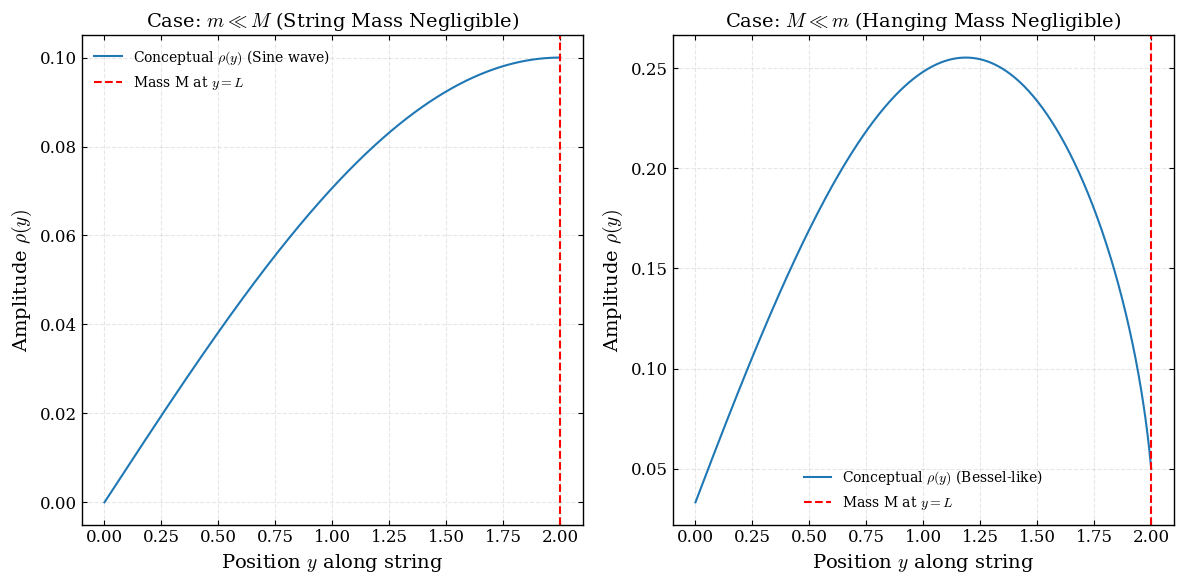

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, yv # For Bessel functions J_0 and Y_0

# --- VISUAL STYLE CONFIGURATION (MATCHING PREVIOUS PLOTS) ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "text.usetex": False, 
    "mathtext.fontset": "cm" # Computer Modern (LaTeX-like)
})

# --- Define fixed parameters ---
L = 2.0   # Length of the string (m)
g = 9.81  # Acceleration due to gravity (m/s^2)

# --- Define the function for rho(y) ---
def rho(y_val, M_val, m_val, omega_val, A_coeff, B_coeff):
    """
    Calculates rho(y) based on the Bessel function solution.
    y_val: position along the string (from 0 to L)
    M_val: hanging mass
    m_val: mass per unit length
    omega_val: angular frequency of the mode
    A_coeff, B_coeff: constants determined by boundary conditions
    """
    
    # Calculate the argument for Bessel functions
    # Note: the definition of z in your text might have a slight typo in the Bessel argument,
    # it typically involves sqrt(omega^2/g) * sqrt(z) or similar, but I'll stick to your provided formula.
    # From your provided equation: sqrt(omega^2 L / g m) * z
    # Let's ensure the argument inside J0 and Y0 is correctly handled.
    # It seems your u(z) definition is: u(z) = A J_0(k*z) + B Y_0(k*z) where k = sqrt(omega^2 L / g m)
    # And rho(y) = sqrt(z) * u(z)
    
    # First, calculate z
    z_val = M_val + (m_val / L) * (L - y_val)
    
    # Calculate the argument for Bessel functions (let's call it 'arg')
    # Make sure omega_val is such that the term under sqrt is positive.
    # The term sqrt(omega^2 L / g m) is a constant for a given mode and system.
    k_bessel = np.sqrt( (omega_val**2 * L) / (g * m_val) )
    
    arg = k_bessel * z_val
    
    # Calculate u(z)
    u_z = A_coeff * jv(0, arg) + B_coeff * yv(0, arg)
    
    # Calculate rho(y)
    rho_y = np.sqrt(z_val) * u_z
    
    return rho_y

# --- Plotting Setup ---
y_values = np.linspace(0, L, 500) # Points along the string

# --- CONCEPTUAL PLOTS (without solving for actual A, B, omega) ---

plt.figure(figsize=(12, 6))

# --- Case 1: m << M (String mass negligible) ---
# Conceptually, this should look like a sine wave (fixed at y=0, free at y=L for fundamental)
# For simplicity, let's plot a sine wave that satisfies a fixed end at y=0 and an antinode (max amplitude) at the pendulum mass M (y=L).
# This is a conceptual representation, not derived from Bessel functions here.
# A fundamental mode of a fixed-free string is a quarter wavelength.
# So, sin(pi/2 * y/L) for the fundamental.

ax1 = plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
M_large = 100.0 # kg
m_small = 0.01  # kg/m

# Hypothetical sine wave for the fundamental mode (conceptual)
# Assuming fixed at y=0, and M is at y=L. The string mode would be a standing wave.
# If the mass M is acting as the primary oscillator, the string might just follow it.
# If we consider the string's own modes, and M acts as a fixed point at y=L for vibration,
# or a "free" end depending on how M interacts.
# Let's assume a simplified "fixed at y=0, free at y=L" string for illustration of harmonic shape.
# For fundamental mode (1/4 wavelength): A sin(pi*y/(2*L))
amp_m_small = 0.1 # Arbitrary amplitude for visualization
rho_m_small_conceptual = amp_m_small * np.sin(np.pi / (2 * L) * y_values)
# Or, if M is the primary oscillator, string just stretches. But it asks for string normal mode.
# So, the conceptual shape is indeed sinusoidal.

plt.plot(y_values, rho_m_small_conceptual, label=r'Conceptual $\rho(y)$ (Sine wave)')
plt.title(r'Case: $m \ll M$ (String Mass Negligible)', fontsize=14)
plt.xlabel('Position $y$ along string', fontsize=14)
plt.ylabel(r'Amplitude $\rho(y)$', fontsize=14)
plt.grid(True, linestyle='--')
plt.axvline(x=L, color='r', linestyle='--', label='Mass M at $y=L$')
plt.legend(frameon=False, fontsize=10)
plt.tick_params(direction='in', top=True, right=True) # Style match


# --- Case 2: M << m (Hanging Mass negligible) ---
ax2 = plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
M_small = 0.01 # kg
m_large = 1.0  # kg/m

# For this case, we'd need actual A, B, omega_n values.
# Since we don't have them, I will just create a placeholder plot
# or use a simplified Bessel form to show the general varying wavelength characteristic.
# Y_0 diverges at 0, so B is often 0 for boundary conditions at z=0 (which is y=L if M is negligible)
# If y=L means z=M, and M is very small, z approaches 0.
# So, often B=0 is chosen to avoid divergence at the free end.
# If B=0, then rho(y) = sqrt(z) * A * J_0(k*z)

# Let's pick an arbitrary omega and A for illustration
# You'd need to solve the eigenvalue problem to get correct omega_n and A, B.
# This is PURELY illustrative of a Bessel-like shape, not an actual solution.
hypothetical_omega_M_small = 5.0 # rad/s (arbitrary)
hypothetical_A_M_small = 0.5 # arbitrary

# We need to handle the case where z_val might be very close to zero for y=L
# For practical plotting, ensure z_val is never exactly zero if using yv which diverges at 0.
# The domain for z is [M, M+m]. y=L corresponds to z=M.
# So y_values from 0 to L maps to z_values from M+m to M.
# The argument for Bessel functions will range from k*(M+m) down to k*M.
# If M is very small, k*M will be very small.

z_values_M_small = M_small + (m_large / L) * (L - y_values)

# Filter out z_values that might cause issues for yv if M_small is exactly 0 and y_values exactly L
# In a real scenario, M_small would not be exactly 0, preventing true divergence.
# For numerical stability, ensure arg is never exactly 0 for Y_0.
# Let's just plot J_0 term, assuming B=0 for now for illustration.
k_bessel_M_small = np.sqrt( (hypothetical_omega_M_small**2 * L) / (g * m_large) )
arg_M_small = k_bessel_M_small * z_values_M_small

# If M_small is very small, z_values_M_small will approach 0 at y=L.
# J_0(x) approaches 1 as x -> 0. Y_0(x) approaches -infinity as x -> 0.
# So if the boundary condition implies finite displacement at M, B must be 0.
rho_M_small_conceptual = np.sqrt(z_values_M_small) * hypothetical_A_M_small * jv(0, arg_M_small)

plt.plot(y_values, rho_M_small_conceptual, label=r'Conceptual $\rho(y)$ (Bessel-like)')
plt.title(r'Case: $M \ll m$ (Hanging Mass Negligible)', fontsize=14)
plt.xlabel('Position $y$ along string', fontsize=14)
plt.ylabel(r'Amplitude $\rho(y)$', fontsize=14)
plt.grid(True, linestyle='--')
plt.axvline(x=L, color='r', linestyle='--', label='Mass M at $y=L$')
plt.legend(frameon=False, fontsize=10)
plt.tick_params(direction='in', top=True, right=True) # Style match

plt.savefig("contoniusplot.pdf")  
plt.tight_layout()
plt.show()

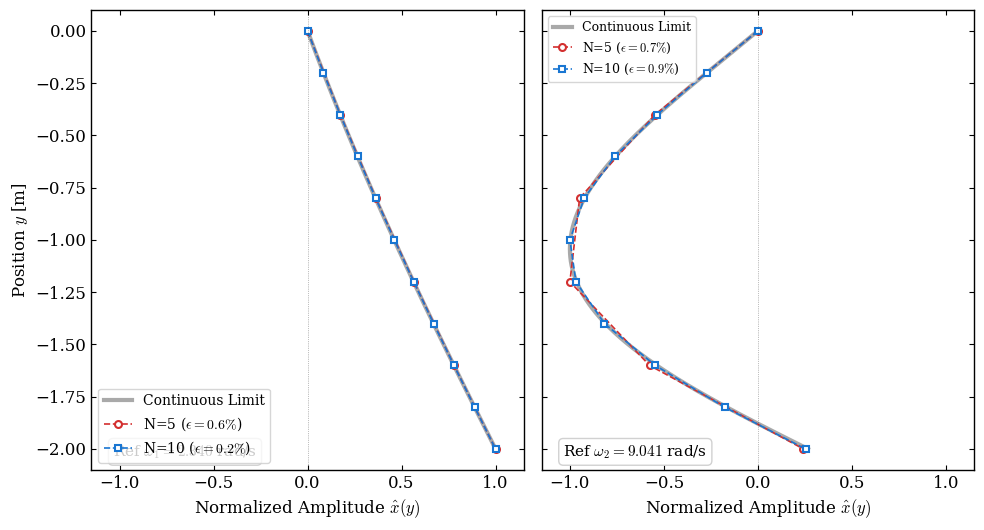

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# --- CONFIGURACIÓN DE ESTILO ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

# --- PARÁMETROS FÍSICOS ---
L_total = 2.0   
m_str = 2.0     
M_load = 2.0    
g = 9.81        

def solve_discrete_system(N):
    """Resuelve autovalores para N eslabones."""
    a = L_total / N           
    dm = m_str / N            
    
    masses = np.full(N, dm)
    masses[-1] = dm + M_load
    
    T_mat = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            start_k = max(i, j)
            mass_sum = np.sum(masses[start_k:])
            T_mat[i, j] = (a**2) * mass_sum
            
    V_mat = np.zeros((N, N))
    for i in range(N):
        mass_sum = np.sum(masses[i:])
        V_mat[i, i] = g * a * mass_sum

    w2, eigenvectors = eigh(V_mat, T_mat)
    idx = np.argsort(w2)
    w2 = w2[idx]
    vecs = eigenvectors[:, idx]
    frequencies = np.sqrt(np.abs(w2))
    
    return frequencies, vecs, a

def get_transverse_displacement(eigenvectors, mode_idx, a, N):
    """
    Convierte theta -> x y NORMALIZA por la AMPLITUD MÁXIMA ABSOLUTA.
    Esto asegura que el gráfico siempre llene el cuadro [-1, 1].
    """
    thetas = eigenvectors[:, mode_idx]
    x_disp = np.cumsum(a * thetas)
    y_pos = -np.linspace(a, L_total, N) 
    
    x_full = np.insert(x_disp, 0, 0)
    y_full = np.insert(y_pos, 0, 0)
    
    # --- MEJORA CLAVE: Normalización robusta ---
    # En lugar de normalizar por la punta, normalizamos por el valor máximo absoluto
    # encontrado en toda la cuerda. Así la 'panza' no se sale del gráfico.
    max_amp = np.max(np.abs(x_full))
    
    # Mantenemos el signo de la punta para consistencia visual (punta a la derecha)
    sign = np.sign(x_full[-1])
    if sign == 0: sign = 1 # Evitar error si la punta es un nodo exacto
    
    x_norm = (x_full / max_amp) * sign
    
    return x_norm, y_full

# --- CÁLCULO ---
N_cont = 1000
freq_c, vecs_c, a_c = solve_discrete_system(N_cont)

N_vals = [5, 10]
results_discrete = []
for n in N_vals:
    f, v, step = solve_discrete_system(n)
    results_discrete.append((n, f, v, step))

# --- GRAFICACIÓN MEJORADA ---
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
modes_to_plot = [0, 1] 

colors_discrete = ['#D32F2F', '#1976D2'] 
markers = ['o', 's'] 

for i, mode_idx in enumerate(modes_to_plot):
    ax = axes[i]
    
    # 1. Modelo Continuo (Referencia)
    xc, yc = get_transverse_displacement(vecs_c, mode_idx, a_c, N_cont)
    # Línea gris oscuro sólida, un poco más gruesa para que se vea la curvatura
    ax.plot(xc, yc, color='#555555', linestyle='-', linewidth=3, alpha=0.5, label='Continuous Limit')
    
    omega_c_val = freq_c[mode_idx]
    
    # 2. Modelos Discretos
    for j, (n, f, v, step) in enumerate(results_discrete):
        xd, yd = get_transverse_displacement(v, mode_idx, step, n)
        omega_val = f[mode_idx]
        err_w = abs(omega_val - omega_c_val)/omega_c_val * 100
        
        label_txt = f'N={n} ($\epsilon={err_w:.1f}\%$)'
        
        # Marcadores un poco más pequeños (markersize 5) para ver mejor la curva
        ax.plot(xd, yd, linestyle='--', marker=markers[j], color=colors_discrete[j],
                markersize=5, markerfacecolor='white', markeredgewidth=1.5,
                linewidth=1.2, label=label_txt)

    # Decoración
    mode_num = mode_idx + 1
    #ax.set_title(f'Normal Mode {mode_num}', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Normalized Amplitude $\hat{x}(y)$', fontsize=12)
    
    # --- MEJORA: Límites fijos y simétricos ---
    # Esto asegura que ambos modos tengan el mismo "marco" visual
    ax.set_xlim(-1.15, 1.15) 
    ax.set_ylim(-L_total*1.05, 0.1)
    
    ax.axvline(0, color='black', linestyle=':', linewidth=0.5, alpha=0.5)
    
    # Texto de frecuencia
    ax.text(0.05, 0.03, f'Ref $\omega_{mode_num} = {omega_c_val:.3f}$ rad/s', 
            transform=ax.transAxes, fontsize=11, 
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='#cccccc', boxstyle='round,pad=0.3'))

    if i == 0:
        ax.set_ylabel('Position $y$ [m]', fontsize=12)
        ax.legend(loc='lower left', frameon=True, fontsize=10)
    else:
        ax.legend(loc='upper left', frameon=True, fontsize=9, handlelength=1.5)

#plt.suptitle(f'Convergence Analysis: Discrete vs Continuous\nparams: L={L_total}m, m={m_str}kg, M={M_load}kg', fontsize=13)
plt.tight_layout()
plt.subplots_adjust(top=0.88) 

plt.savefig('discrete_vs_continuous_fixed.png', dpi=300)
plt.show()